# Data Analytics - Summative Assessment One

## Business Case
As a part of a software development team for Censored, I have been asked to conduct data-driven analysis of games on the online gaming marketplace Steam.  The purpose of this analysis is to make informed data-driven decisions on what type of game the organisation should produce in order to maximise audience reach, engagement, and cost-effectiveness.  

By examining existing games on Steam, this project aims to identify patterns in the games' popularity, reception, player engagement, tags, genres, or combinations of genres.  The aim of these insights is to create a game with the maximum reach possible to provide the greatest return on investment.  


*** name audience get usful stuf claim it was the plan.  Talk abot audience competence

## Data acquisition 





### Import Python Modules 🐍

In [571]:
import pandas as pd # Pandas is a module for data manipulation, it makes use of dataframe objects to store and manipulate data.
import numpy as np # Numpy is a module for numerical computing, it provides support for arrays and matrices and mathematical functions.
import matplotlib.pyplot as plt # Matplotlib is a module for data visualization.
import seaborn as sns # Seaborn is a module for statistical data visualization, built on top of Matplotlib.
import plotly.express as px # Plotly Express is a module for making interactive visualisations.
from itertools import combinations # Combinations is a module for creating combinations of items.

### Loading dataset 📥

In [572]:
steam_games_df = pd.read_csv("steam_games.csv")

This creates a pandas dataframe object from the origional csv file.  The reason the dataframe object are so effective for data analysis is that they have built in methods and functions which enable the user to quickly and easily inspect and transform the data.

### Dataset source and description
This analysis uses the [Steam Games Dataset](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset), a public open dataset from Kaggle.  The dataset provides comprehensive information on the games sold on Steam, including commercial, technical and user engagement data.

## Initial data inspection 🧭

### Preview the data

In [573]:
steam_games_df.head(2)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN


On initially looking at the dataframes head it apears that there is a missing column name.  Due to 'supported languages' being languages, 'about the game' being text and price being in the format x.xx it makes sense that the 'DiscountDLC Count' should be two columns.  This is a mistake present in the kaggle dataset.  To fix 'DiscountDLC Count' was split into 'Discount' and 'DLC Count' by a comma.  
  
Overall this isn't very usful as it only shows a few columns potentially hiding errors.

In [574]:
steam_games_df.shape

(122611, 40)

The shape of the dataframe is 40 columns and 122611 rows.  This means that there are 40 columns and 122611 rows.  40 columns are too many for this investigation, any extra colums will just confuse.  Furthermore there are way to many rows for the data to ever be manually checked by a human. 

### Check columns

In [575]:
steam_games_df.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='str')

Column names are mostly self explanatory with the exeption of a few such as 'Posative' and 'Negative' which need aditional context to make sense.

### Check datatypes

In [576]:
steam_games_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  int64  
 1   Name                        122610 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   Discount                    122611 non-null  int64  
 8   DLC count                   122611 non-null  int64  
 9   About the game              114162 non-null  str    
 10  Supported languages         122611 non-null  str    
 11  Full audio languages        122611 non-null  str    
 12  Reviews                     12070 non-null   str    
 13  Header image             

Overall the dataframe has a mix of quantitative and qualitative data.  Data type is mostly correct except columns like 'release date' which should be a date and 'Estimated Owners' should be an integer.  There are also a few unusable columns due to lack of data such as 'Movies', 'Notes' or 'Score Rank'.

In [577]:
steam_games_df.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


.describe() shows sumary statistics for numerical colums.  
Quite a few of the third quartile are 0, this is due to a large number of 0 results biasing the data some such as 'DLC Count' are probuably legitimate however for 'User score' and 'Metacritic score' no score is probuably recorded as 0.  
Columns like 'Positive', 'Negative' and 'Recomondation' columns have a median of 5, 1 and 0 respectivly but means of 1 x 10E3, 2 x 10E2 and 2 x 10E2, this large difference between the median and mean sugests a few extremly popular games with high engagment.
The 'movies' column contains no legitimate data and should be removed.

In [578]:
steam_games_df.describe(include='str')

,Name,Release date,Estimated owners,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Metacritic url,Notes,Developers,Publishers,Categories,Genres,Tags,Screenshots
count,122610,122611,122611,114162,122611,122611,12070,122530,49676,54142,100348,4256,22458,114174,113702,113658,114198,83346,116593
unique,121454,5081,14,113556,19113,3710,11884,122420,39703,35393,60515,4160,18619,70812,62684,13291,2894,77179,116483
top,Shadow of the Tomb Raider: Definitive Edition,"Oct 23, 2025",0 - 20000,Help the beautiful girls to immerse themselves...,['English'],[],"“🏆 I loved! ❤️❤️❤️” Player “🏆 Cute kittens, ea...",https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,info@bigfishgames.com,https://www.metacritic.com/game/pc/shadow-of-t...,This Game may contain content not appropriate ...,EroticGamesClub,BFG Entertainment,"Single-player,Family Sharing","Casual,Indie","Adventure,Casual,Hidden Object",https://shared.akamai.steamstatic.com/store_it...
freq,20,190,75404,65,55314,72730,43,20,274,328,323,20,181,231,554,23383,6700,273,20


.describe(include="str") shows sumary statistics for string colums.  
The name column contains 121454 unique vaues out of 122610 records, 'Shadow of the Tomb Raider: Definitive Edition' apears 20 times sugesting duplicate records in the dataset.  
Estimated owners shows a range of owners therfore for analysis it may be usful to split into minimum and maximum columns.    
The catagorical data columns 'Catagories', 'Genres' and 'Tags' contain comma seperated strings which requere processing before used in analysis.

### Check missing

In [579]:
missing_values = steam_games_df.isnull().sum()
missing_values

AppID                              0
Name                               1
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
Discount                           0
DLC count                          0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
R

Out of the 122611 records in this data 118355 do not have a metacritic url, this shows that the vast magority of games are unknown and do not get a critic score.  

Approximatly 6 - 8 % of games are missing data in columns which would normally be expected such as 'Screenshots', 'Developers' or 'About the game'.  This may indicate there is duplicated data, demos being counted, incomplete enteries or somthing else which needs to be investigated.

Overall the dataset is largly clean and requires minimal preparation.  Duplicates need to be found and removed, columns without a use in this investigation need to be removed and some columns need to be renamed for clarity.  'Release date' needs to be a date, 'Estimated owners' needs altering to an integer and 'Genres' and 'Tags' need explanding so they can be used in visualisations.

## Data cleaning 🛀🏾

### Remove Duplicates

In [580]:
steam_games_df.duplicated().sum()

np.int64(0)

This code counts duplicated records.  This means there are no completly duplicated records but does not meen that there are no records for the same game.

In [581]:
steam_games_df["AppID"].duplicated().sum()

np.int64(0)

This code counts duplications in the 'AppID' column.  The games 'AppID' is unique meaning there are no repeated records based on this identifier.

In [582]:
steam_games_df["Name"].duplicated().sum()

np.int64(1156)

This code counts duplications in the 'Name' column.  There are duplicates based on 'Name' which need investigating to see if they are duplications.

In [583]:
steam_games_df[steam_games_df["Name"].duplicated(keep=False)].sort_values("Name").head(6)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
108086,3763930,A Better Tomorrow,"Sep 30, 2025",0 - 0,0,0,0.00,0,0,"Rabies erupts without warning, rupturing the y...",...,0,0,0,WoofWoofStudio,WoofWoofStudio,"Single-player,Steam Achievements,Custom Volume...","Indie,Free To Play,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
30085,3022780,A Better Tomorrow,"Jul 31, 2024",0 - 20000,0,0,0.00,0,0,A Better Tomorrow is a minimalist 2D city-buil...,...,0,0,0,GoragarX,GoragarX,Single-player,"Casual,Strategy,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
53193,557900,A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.00,0,0,Most of humanity lives in urban environments. ...,...,0,0,0,Brightdawn Entertainment,Brightdawn Entertainment,"Single-player,Full controller support,Tracked ...","Indie,Simulation","Indie,Simulation,VR,Singleplayer,Family Friendly",https://shared.akamai.steamstatic.com/store_it...,NaN
62608,842420,A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.00,0,0,"Find Your Friends! Over the years, dozens of c...",...,0,13,0,Something Dark Studios,Something Dark Studios,"Multi-player,PvP,Online PvP,Co-op,Online Co-op...","Adventure,Free To Play,Indie","Free to Play,Horror,Multiplayer,Indie,Adventur...",https://shared.akamai.steamstatic.com/store_it...,NaN
100222,1826070,ALONE,"Dec 23, 2021",0 - 20000,0,0,8.99,0,0,It all started with a normal night shift duty....,...,0,0,0,True Nuke,True Nuke,"Single-player,Family Sharing","Action,Adventure,Indie","Psychological Horror,Exploration,Action,Hero S...",https://shared.akamai.steamstatic.com/store_it...,NaN
17238,1544540,ALONE,"May 31, 2021",50000 - 100000,0,0,0.74,0,0,ALONE is a horror adventure game. You have to ...,...,0,0,0,DakeCraft,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual,Indie","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horr...",https://shared.akamai.steamstatic.com/store_it...,NaN


Looking at the 'Release Date','About the game' and 'Developer' it apears that the records are not duplicated.

In [584]:
steam_games_df[steam_games_df.duplicated(subset=["Name", "Release date", "About the game"],keep=False)].sort_values(["Name", "Release date", "About the game"]).head(6)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
78035,34010,Alpha Protocol™,"Jun 1, 2010",500000 - 1000000,10,17,9.99,50,0,Loyalty carries a price and no one knows this ...,...,0,118,0,Obsidian Entertainment,SEGA,"Single-player,Family Sharing","Action,RPG","RPG,Stealth,Choices Matter,Action,Multiple End...",https://shared.akamai.steamstatic.com/store_it...,NaN
108996,34019,Alpha Protocol™,"Jun 1, 2010",0 - 20000,0,17,9.99,50,0,Loyalty carries a price and no one knows this ...,...,0,0,0,Obsidian Entertainment,SEGA,"Single-player,Family Sharing","Action,RPG","RPG,Stealth,Action,Choices Matter,Multiple End...",https://shared.akamai.steamstatic.com/store_it...,NaN
63287,33230,Assassin's Creed 2,"Mar 9, 2010",2000000 - 5000000,188,17,4.99,75,0,Assassin’s Creed® 2 is the follow-up to the ti...,...,473,538,411,Ubisoft Montreal,Ubisoft,Single-player,"Action,Adventure","Action,Open World,Parkour,Assassin,Stealth,Adv...",https://shared.akamai.steamstatic.com/store_it...,NaN
83437,48173,Assassin's Creed 2,"Mar 9, 2010",0 - 20000,0,17,4.99,75,0,Assassin’s Creed® 2 is the follow-up to the ti...,...,0,0,0,Ubisoft Montreal,Ubisoft,Single-player,"Action,Adventure","Action,Open World,Parkour,Adventure,Stealth,As...",https://shared.akamai.steamstatic.com/store_it...,NaN
73217,22350,BRINK,"May 9, 2011",500000 - 1000000,22,0,0.00,0,3,Brink is an immersive first-person shooter tha...,...,0,80,0,Splash Damage,Bethesda Softworks,"Single-player,Multi-player,Co-op,Steam Achieve...","Action,Free To Play","FPS,Action,Multiplayer,Parkour,Shooter,Charact...",https://shared.akamai.steamstatic.com/store_it...,NaN
73810,22360,BRINK,"May 9, 2011",0 - 20000,0,0,0.00,0,3,Brink is an immersive first-person shooter tha...,...,0,0,0,Splash Damage,Bethesda Softworks,"Single-player,Multi-player,Co-op,Steam Achieve...","Action,Free To Play","FPS,Action,Multiplayer,Parkour,Shooter,Charact...",https://shared.akamai.steamstatic.com/store_it...,NaN


This code finds the records with the same "Name", "Release date" and "About the game".  Looking at rows with the same 'Name', 'Release Date' and 'About the Game' there apears to be duplicates.  The duplicate with the lower 'AppID' apear to be real as it has a entry for 'Peak CCU' which means Peak Concurrent Players therefore as a future peak cant be lowwer than the current peak the entry with the lower 'AppID' must be more accurate.

In [585]:
steam_games_df = steam_games_df.drop_duplicates(subset=["Name", "Release date", "About the game"], keep="first")

This code removes the duplicates with the same "Name", "Release date" and "About the game" keeping the first record.

In [586]:
steam_games_df[steam_games_df.duplicated(subset=["Name", "Release date"],keep=False)].sort_values(["Name", "Release date"]).shape

(0, 40)

This code shows that there are no more duplicates with the same "Name" and "Release date".

In [587]:
steam_games_df[steam_games_df["Name"] == "Assassin's Creed 2"]

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
63287,33230,Assassin's Creed 2,"Mar 9, 2010",2000000 - 5000000,188,17,4.99,75,0,Assassin’s Creed® 2 is the follow-up to the ti...,...,473,538,411,Ubisoft Montreal,Ubisoft,Single-player,"Action,Adventure","Action,Open World,Parkour,Assassin,Stealth,Adv...",https://shared.akamai.steamstatic.com/store_it...,NaN


This code shows that the correct duplicate was kept as can be seen by the 'Peak CCU' being 188.

I checked for full duplicates and found there were none.  I knew however that there were duplicates due to the initial investigation.  I then checked for duplicates in 'AppID' and there were none.  I then checked for duplicates in 'Name', there were 1156 I then checked the whole row and realised every duplicate was a single duplicate with the same 'Name', 'Release Date' and 'Catagory' but a higher AppID and less data including no Peak PCC.  Due to theis I realised the First needed to be kept.  Finally I checked to see if the correct record was kept.

### Remove Unnesesary Columns

In [588]:
steam_games_df = steam_games_df.drop(columns=['Required age', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime two weeks',
       'Median playtime two weeks', 'Developers', 'Reviews',
       'Publishers', 'Screenshots', 'Movies'])

This code removes all of the columns which are unnessisary for this investigation.

In [589]:
steam_games_df.head(2)

,AppID,Name,Release date,Estimated owners,Peak CCU,Price,Metacritic score,Metacritic url,User score,Positive,Negative,Average playtime forever,Median playtime forever,Categories,Genres,Tags
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0.00,0,NaN,0,0,0,0,0,NaN,NaN,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,5.24,0,NaN,0,252,3,8,8,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"


### Convert Datatypes and Create Useful Columns

In [590]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122500 entries, 0 to 122610
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AppID                     122500 non-null  int64  
 1   Name                      122499 non-null  str    
 2   Release date              122500 non-null  str    
 3   Estimated owners          122500 non-null  str    
 4   Peak CCU                  122500 non-null  int64  
 5   Price                     122500 non-null  float64
 6   Metacritic score          122500 non-null  int64  
 7   Metacritic url            4194 non-null    str    
 8   User score                122500 non-null  int64  
 9   Positive                  122500 non-null  int64  
 10  Negative                  122500 non-null  int64  
 11  Average playtime forever  122500 non-null  int64  
 12  Median playtime forever   122500 non-null  int64  
 13  Categories                113547 non-null  str    
 14  Genr

'Release date' is a string and not a date.

In [591]:
steam_games_df['Release date'] = pd.to_datetime(steam_games_df['Release date'], errors='coerce')

This code changes the 'Release date' string into datetime64[us], errors='coerce' stops the code failing if it doesn' find a date and instead puts NaT which means Not a Time.

In [592]:
steam_games_df[['Estimated owners min','Estimated owners max']]= (steam_games_df['Estimated owners'].str.split(' - ', expand=True).astype(int))

This code splits the 'Estimated owners' string into 'Estimated owners min' and 'Estimated owners max' integers.

In [593]:
steam_games_df['Estimated owners'].unique()

<StringArray>
[                '0 - 0',             '0 - 20000',       '100000 - 200000',
      '500000 - 1000000',         '20000 - 50000',       '200000 - 500000',
        '50000 - 100000',     '2000000 - 5000000',   '10000000 - 20000000',
     '1000000 - 2000000',   '20000000 - 50000000',    '5000000 - 10000000',
 '100000000 - 200000000',  '50000000 - 100000000']
Length: 14, dtype: str

This code lists all of the unique strings in 'Estimated owners'.  It shows that there is a huge range within the estimation.  This is not usful so a 'Estimated owners middle' will be created.

In [594]:
steam_games_df['Estimated owners middle'] = ((steam_games_df['Estimated owners min'] + steam_games_df['Estimated owners max']) / 2).astype(int)

This code creates 'Estimated owners middle' by finding the mean of min and max.

In [595]:
steam_games_df['Interactions'] = steam_games_df['Positive'] + steam_games_df['Negative']

This code creates an 'Interactions' column by summing the 'Positive' and 'Negative' columns.

In [596]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122500 entries, 0 to 122610
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   AppID                     122500 non-null  int64         
 1   Name                      122499 non-null  str           
 2   Release date              122500 non-null  datetime64[us]
 3   Estimated owners          122500 non-null  str           
 4   Peak CCU                  122500 non-null  int64         
 5   Price                     122500 non-null  float64       
 6   Metacritic score          122500 non-null  int64         
 7   Metacritic url            4194 non-null    str           
 8   User score                122500 non-null  int64         
 9   Positive                  122500 non-null  int64         
 10  Negative                  122500 non-null  int64         
 11  Average playtime forever  122500 non-null  int64         
 12  Median playtime fo

### Split Multi Value Catagorical Data
The 'Genres' and 'Tags' columns contain catagorical data pertaining to what kind of game it is.  This needs to be spit out of the main table so it can be used in the statistics and visualisations.

In [597]:
steam_games_df['Genre / Tags'] = steam_games_df['Genres'].fillna('') + ',' + steam_games_df['Tags'].fillna('')

This code creates a 'Genre_Tags' column by combining the 'Genres' and 'Tags' columns.  This is done as the date within these columns is inconsistant or duplicated and a combined column gives the data which is needed.

In [598]:
genres_tags_df = steam_games_df[['AppID','Genre / Tags']].copy()
genres_tags_df.head(4)

,AppID,Genre / Tags
0,2539430,","
1,496350,"Adventure,Adventure,Visual Novel,Anime,Cute"
2,1034400,"Casual,Casual,Card Game,Solitaire,Puzzle,Hidde..."
3,3292190,"Casual,Indie,Simulation,"


This code copies the 'AppID' and 'Genre / Tags' column in the steam_games_df dataframe.

In [599]:
genres_tags_df['Genre / Tags'] = genres_tags_df['Genre / Tags'].str.split(',')
genres_tags_df.head(4)

,AppID,Genre / Tags
0,2539430,"[, ]"
1,496350,"[Adventure, Adventure, Visual Novel, Anime, Cute]"
2,1034400,"[Casual, Casual, Card Game, Solitaire, Puzzle,..."
3,3292190,"[Casual, Indie, Simulation, ]"


This code splits the string into a python list which will be used by the next stage.

In [600]:
genres_tags_df = genres_tags_df.explode('Genre / Tags')
genres_tags_df.head(5)

,AppID,Genre / Tags
0,2539430,
0,2539430,
1,496350,Adventure
1,496350,Adventure
1,496350,Visual Novel


This code explodes the 'Genre / Tags' column expanding the rows.

In [601]:
genres_tags_df = genres_tags_df.drop_duplicates()
genres_tags_df.head(10)

,AppID,Genre / Tags
0,2539430,
1,496350,Adventure
1,496350,Visual Novel
1,496350,Anime
1,496350,Cute
2,1034400,Casual
2,1034400,Card Game
2,1034400,Solitaire
2,1034400,Puzzle
2,1034400,Hidden Object


This code removes duplicates which is important as many of the Genres and Tags were the same.

In [602]:
genres_tags_df = genres_tags_df[genres_tags_df['Genre / Tags'] != ""]
genres_tags_df.head(5)

,AppID,Genre / Tags
1,496350,Adventure
1,496350,Visual Novel
1,496350,Anime
1,496350,Cute
2,1034400,Casual


This code removes the 'Genre / Tags' data which is an empty string, this is important as empty strings were added when the Genres and Tags columns were combined then split.

In [603]:
for genre in sorted(genres_tags_df['Genre / Tags'].unique()):
    print(genre,end=', ')

1980s, 1990's, 2.5D, 2D, 2D Fighter, 2D Platformer, 360 Video, 3D, 3D Fighter, 3D Platformer, 3D Vision, 4 Player Local, 4X, 6DOF, 8-bit Music, ATV, Abstract, Accounting, Action, Action RPG, Action RTS, Action Roguelike, Action-Adventure, Addictive, Adventure, Agriculture, Aliens, Alternate History, Ambient, America, Animation & Modeling, Anime, Arcade, Archery, Arena Shooter, Artificial Intelligence, Assassin, Asymmetric VR, Asynchronous Multiplayer, Atmospheric, Audio Production, Auto Battler, Automation, Automobile Sim, BMX, Base-Building, Baseball, Based On A Novel, Basketball, Battle Royale, Beat 'em up, Beautiful, Benchmark, Bikes, Birds, Blood, Board Game, Boomer Shooter, Boss Rush, Bowling, Boxing, Building, Bullet Hell, Bullet Time, CRPG, Capitalism, Card Battler, Card Game, Cartoon, Cartoony, Casual, Cats, Character Action Game, Character Customization, Chess, Choices Matter, Choose Your Own Adventure, Cinematic, City Builder, Class-Based, Classic, Clicker, Co-op, Co-op Campa

This code lists all of the 'Genre / Tags'.

### Handle Missing Values

In [604]:
steam_games_df.loc[(steam_games_df['Metacritic score']==0)&steam_games_df['Metacritic url'].isnull(), 'Metacritic score'] = np.nan

This code removes the 'Metacritic Score' when it is 0 and there is no 'Metacritic url'.  This is because it is unlikly if both things are true that there is a score.

In [605]:
steam_games_df["Metacritic score"] = steam_games_df["Metacritic score"].astype("Int64")

This code changes the float datatype to Int64 which is a pandas nullable integer.  NaN gets changed to NA.

In [606]:
steam_games_df.loc[(steam_games_df['User score']==0), 'User score'] = np.nan

This code replaces the 'User score' value of 0 with NaN.  This is due to it being extremly unlikly for multiple users to give a game a 0.

In [607]:
steam_games_df = steam_games_df.dropna(subset=["Name"])

Removes records with no name.

In [608]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122499 entries, 0 to 122610
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   AppID                     122499 non-null  int64         
 1   Name                      122499 non-null  str           
 2   Release date              122499 non-null  datetime64[us]
 3   Estimated owners          122499 non-null  str           
 4   Peak CCU                  122499 non-null  int64         
 5   Price                     122499 non-null  float64       
 6   Metacritic score          4194 non-null    Int64         
 7   Metacritic url            4194 non-null    str           
 8   User score                40 non-null      float64       
 9   Positive                  122499 non-null  int64         
 10  Negative                  122499 non-null  int64         
 11  Average playtime forever  122499 non-null  int64         
 12  Median playtime fo

Out of 122500 games there are only 4194 Megacritic scores and only 40 User scores.  Therefore 'User score' will be removed as it is no use.

### Removing Intermediate Columns

In [609]:
steam_games_df = steam_games_df.drop(columns=['User score', 'Estimated owners', 'Estimated owners min', 'Estimated owners max','Categories', 'Genres', 'Tags', 'Genre / Tags', 'Metacritic url'])

### Verify Cleaning 🛀🏾

In [610]:
steam_games_df.sample(8)

,AppID,Name,Release date,Peak CCU,Price,Metacritic score,Positive,Negative,Average playtime forever,Median playtime forever,Estimated owners middle,Interactions
34986,916130,Meet the Miner - WDR VR Bergwerk,2018-09-20,0,0.00,<NA>,40,9,0,0,35000,49
94439,2236960,Qiybz,2023-02-02,0,0.00,<NA>,2,2,0,0,10000,4
46636,873860,Pop Island - Let's Code !!!,2018-07-13,0,9.99,<NA>,2,1,0,0,10000,3
16869,1960890,Jishogi,2022-06-23,0,2.49,<NA>,66,0,0,0,10000,66
71796,622700,War Heroes: Invasion,2018-05-15,0,2.99,<NA>,22,16,217,217,10000,38
70272,2077580,Destroiders,2023-02-03,0,3.99,<NA>,2,0,0,0,35000,2
120182,1689550,Your Adventure,2021-07-23,0,0.00,<NA>,0,0,0,0,0,0
112753,2211260,Something's Out There,2024-10-29,0,3.74,<NA>,3,5,0,0,10000,8


This code shows a sample of 8 random rows.  All the data looks correct and all the datatypes look correct.

In [611]:
steam_games_df.info()

<class 'pandas.DataFrame'>
Index: 122499 entries, 0 to 122610
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   AppID                     122499 non-null  int64         
 1   Name                      122499 non-null  str           
 2   Release date              122499 non-null  datetime64[us]
 3   Peak CCU                  122499 non-null  int64         
 4   Price                     122499 non-null  float64       
 5   Metacritic score          4194 non-null    Int64         
 6   Positive                  122499 non-null  int64         
 7   Negative                  122499 non-null  int64         
 8   Average playtime forever  122499 non-null  int64         
 9   Median playtime forever   122499 non-null  int64         
 10  Estimated owners middle   122499 non-null  int64         
 11  Interactions              122499 non-null  int64         
dtypes: Int64(1), datet

This code shows info on the cleaned dataframe.  There are no missing values, except 'Metacritic score'.  All the datatypes are applicible to the date in the columns.

In [612]:
genres_tags_df.info()

<class 'pandas.DataFrame'>
Index: 1299439 entries, 1 to 122610
Data columns (total 2 columns):
 #   Column        Non-Null Count    Dtype
---  ------        --------------    -----
 0   AppID         1299439 non-null  int64
 1   Genre / Tags  1299439 non-null  str  
dtypes: int64(1), str(1)
memory usage: 29.7 MB


This code shows the info on the genres_tags_df dataframe.  No data is missing and the datatypes are correct.

## Exploratory data analysis

### Summary statistics

In [613]:
steam_games_summary = steam_games_df.describe()
steam_games_summary

,AppID,Release date,Peak CCU,Price,Metacritic score,Positive,Negative,Average playtime forever,Median playtime forever,Estimated owners middle,Interactions
count,1.224990e+05,122499,1.224990e+05,122499.000000,4194.0,1.224990e+05,1.224990e+05,1.224990e+05,1.224990e+05,1.224990e+05,1.224990e+05
mean,1.986674e+06,2022-01-23 22:58:16.407317,5.373861e+01,4.761049,73.815212,1.013920e+03,1.628644e+02,2.075578e+02,1.734805e+02,8.457763e+04,1.176785e+03
min,1.000000e+01,1997-06-30 00:00:00,0.000000e+00,0.000000,6.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.064590e+06,2019-12-27 00:00:00,0.000000e+00,0.550000,68.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+04,0.000000e+00
50%,1.908600e+06,2022-11-16 00:00:00,0.000000e+00,2.240000,75.0,5.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+04,7.000000e+00
75%,2.870305e+06,2024-10-04 00:00:00,0.000000e+00,5.240000,81.0,3.700000e+01,1.000000e+01,0.000000e+00,0.000000e+00,1.000000e+04,4.900000e+01
max,4.264350e+06,2026-01-05 00:00:00,1.013936e+06,999.980000,97.0,7.642084e+06,1.173003e+06,3.429544e+06,3.429544e+06,1.500000e+08,8.815087e+06
std,1.086905e+06,NaN,3.726246e+03,12.529929,10.287702,2.781956e+04,5.322480e+03,1.122265e+04,1.120763e+04,1.283792e+06,3.231070e+04


*** explain all the statistics and what it shows about the data.

These statistics are highly skewed as most games have very low or 0 interactions and a few games have very high interactions.  

For example the average 'Peak CCU' or peak concurrent players is 54 but yhe medium is 0 and the 75th percentile is 0, which means that 75% of the games have 0 peak concurrent players.  The maximum 'Peak CCU' is over a million which is a huge outlier.  

The same thing is true for 'Median playtime forever', 75% of the games on steam have a medium playtime of 0 yet the maximum has a medium playtime of over 1000 hours.  

There are only 4194 games with a metacritic score, this is due to many games not getting a score and steam removing the score from their store page in favour of user reviews, therefore the information isn't representative or usful.  It is interesting to see though that the data is scewed left and that critics give 50% of the gavmes they review a score of 75/100.  

'Estimated owners middle' is a calculated column from very large ranges and is therfore not usful.  The magority of games most probuably sold no copies.

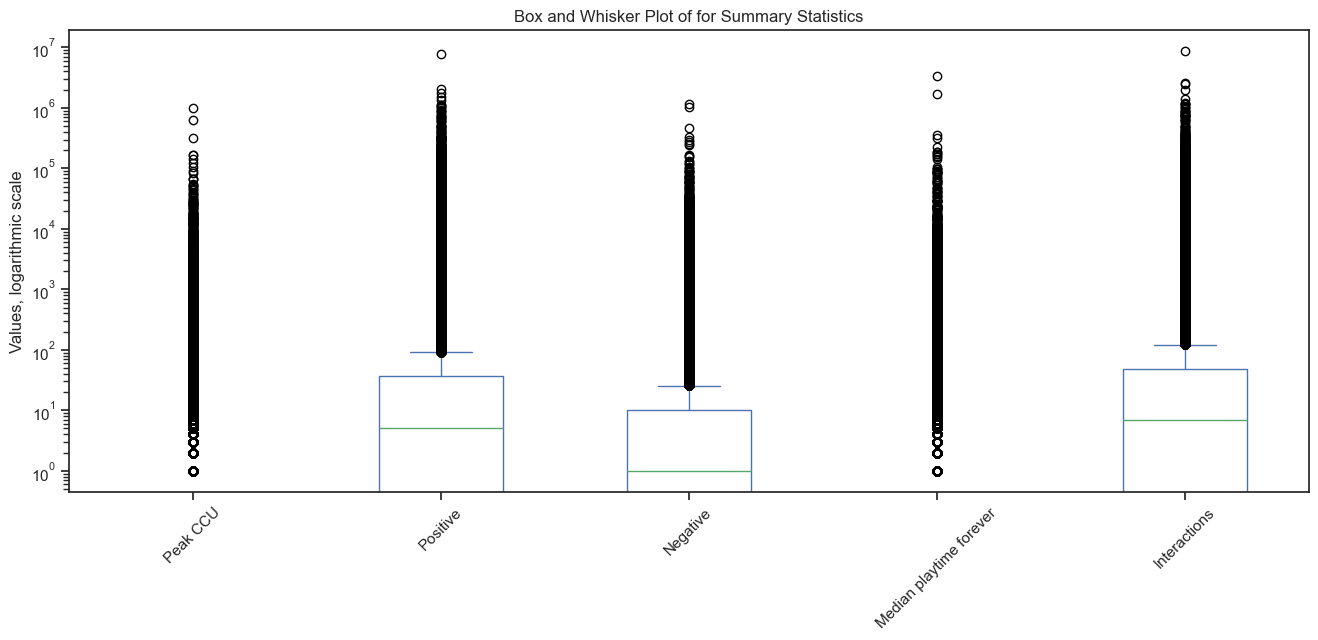

In [614]:
steam_games_df[[
    "Peak CCU",
    "Positive",
    "Negative",
    "Median playtime forever",
    "Interactions"
]].plot(
    kind="box",
    figsize=(16, 6),
    logy=True
    )

plt.title("Box and Whisker Plot of for Summary Statistics")

plt.ylabel("Values, logarithmic scale")
plt.xticks(rotation=45)
plt.show()

Like the summary statistics these box plots show that the magority of games have very low or 0 values and a few have extremly high values.  

Data is so spread out that it thinks all of the data are outliers.

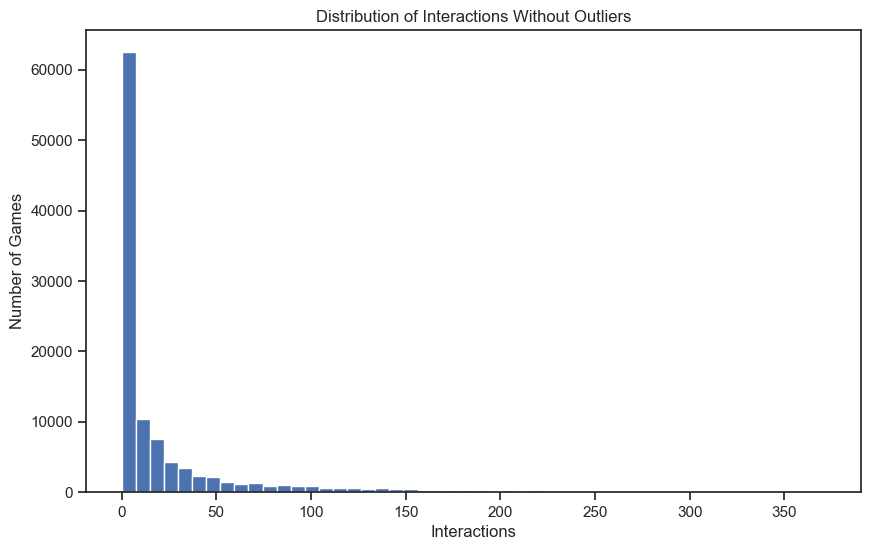

In [696]:
upper_limit = steam_games_df["Interactions"].quantile(0.9)

plot_df = steam_games_df[steam_games_df["Interactions"] <= upper_limit]

plt.figure(figsize=(10, 6))

plt.hist(plot_df["Interactions"], bins=50)

plt.title("Distribution of Interactions Without Outliers")
plt.xlabel("Interactions")
plt.ylabel("Number of Games")

plt.show()

The data is heavily sqewed right, the vast majority of games have 0 interactions, most have low interactions and some have higher interactions.

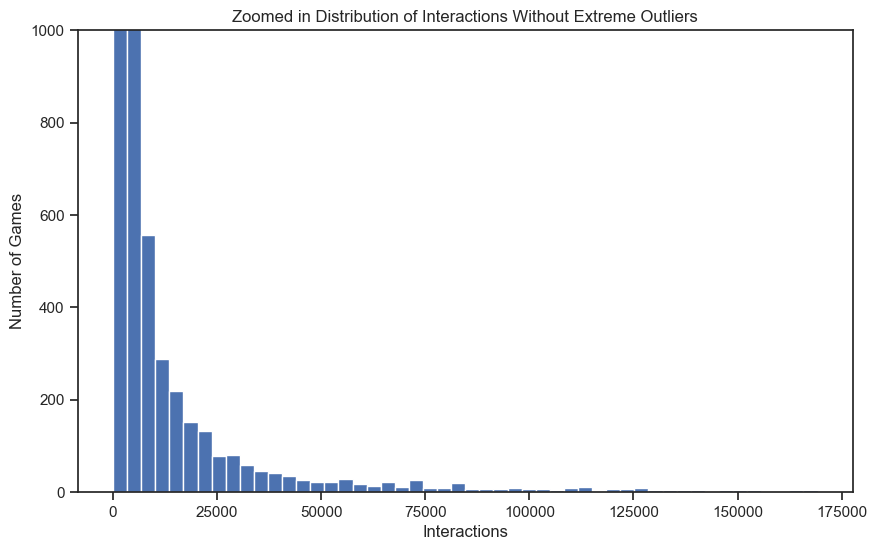

In [699]:
upper_limit = steam_games_df["Interactions"].quantile(0.999)

plot_df = steam_games_df[
    steam_games_df["Interactions"] <= upper_limit
]

plt.figure(figsize=(10, 6))

plt.hist(plot_df["Interactions"], bins=50)

plt.ylim(0, 1000)

plt.title("Zoomed in Distribution of Interactions Without Extreme Outliers")
plt.xlabel("Interactions")
plt.ylabel("Number of Games")

plt.show()

This is a zoomed in version of the previous graph.  Also more outliers have been alowed as .quantile(0.9) has been changed to .quantile(0.999).

The data is still heavily sqewed right.  Showing more of what would be considered outliers shows how sqewed the data is.

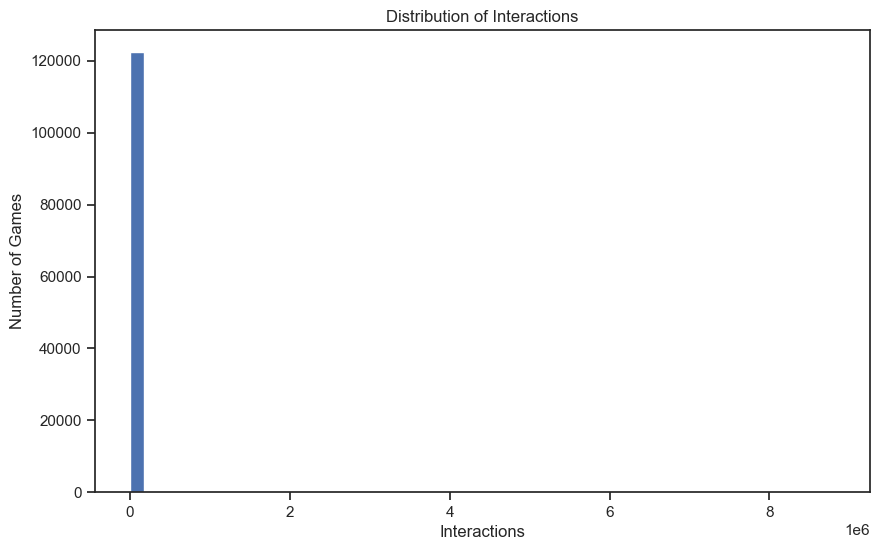

In [677]:
plt.figure(figsize=(10, 6))

plt.hist(
    steam_games_df["Interactions"],
    bins=50
)

plt.title("Distribution of Interactions")
plt.xlabel("Interactions")
plt.ylabel("Number of Games")

plt.show()

### Genres Tags Investigation

In [615]:
games_plus_tags_df = steam_games_df.merge(genres_tags_df, on="AppID", how="left")
games_plus_tags_df.head(8)

,AppID,Name,Release date,Peak CCU,Price,Metacritic score,Positive,Negative,Average playtime forever,Median playtime forever,Estimated owners middle,Interactions,Genre / Tags
0,2539430,Black Dragon Mage Playtest,2023-08-01,0,0.00,<NA>,0,0,0,0,0,0,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,<NA>,252,3,8,8,10000,255,Adventure
2,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,<NA>,252,3,8,8,10000,255,Visual Novel
3,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,<NA>,252,3,8,8,10000,255,Anime
4,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,5.24,<NA>,252,3,8,8,10000,255,Cute
5,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,4.99,<NA>,21,3,0,0,10000,24,Casual
6,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,4.99,<NA>,21,3,0,0,10000,24,Card Game
7,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,4.99,<NA>,21,3,0,0,10000,24,Solitaire


In [616]:
games_plus_tags_df['Genre / Tags'].value_counts().head(20)

Genre / Tags
Indie             83058
Casual            54492
Singleplayer      50274
Adventure         49279
Action            49026
2D                26784
Simulation        26223
Strategy          24416
RPG               22567
3D                17993
Puzzle            16338
Atmospheric       16233
Colorful          14260
Pixel Graphics    13867
Early Access      13533
Story Rich        13307
Exploration       13217
Cute              12678
First-Person      12267
Free To Play      12161
Name: count, dtype: int64

'Indie', 'Free To Play' and 'Singleplayer' arnt usful tags as their aditional advertising terms rather than information about the type of game.  Same with 2D and 3D although these are more for search terms and visability.

In [665]:
genres_tags_filtered_df = games_plus_tags_df[~games_plus_tags_df['Genre / Tags'].isin([
    'Singleplayer', 'Multiplayer', 'Early Access', 'Free To Play',
    'Massively Multiplayer', 'MMORPG', 'PvP', 'PvE', '2D', '3D', 'Indie',
    'Classic','Reboot', 'Lara Croft', 'Masterpiece', 'Mod', 'Online Co-Op', 'Local Co-Op', 'Split Screen', 
    'Shared/Split Screen', 'Controller', 'Steam Cloud', 'Remote Play Together', 'Remote Play on Phone', 'Remote Play on Tablet', 'Remote Play on TV',
    'Well Written', 'Sequel', 'Prequel', 'Remake', 'Remastered', 'DLC', 'Expansion', 'Soundtrack', 'Early Access', 'Free To Play', 'Cult Classic', 
    'Kickstarter', '3D Vision', '4 Player Local', '4 Player Online', '4 Player Co-Op', 'Steam Machine', 'TrackIR', 'VR', 'Virtual Reality', 'Oculus Rift', 'HTC Vive', 'Valve Index', 'Windows Mixed Reality'
    'Free To Play', 'Benchmark', 'Touch-Friendly', 'Moddable', 'Animation & Moddeling', 'TrackIR', 'Games Workshop', 'Free to Play', 'Competitive', 'Episodic', 
    'Well-Written', 'Hardware', 'Mature', 'Nudity', 'NSFW', 'Co-op', 'Nostalgia', 'Sexual Content', 'Great Soundtrack'
    ])]

This code filters out common generic tags which dont really describe the genre of the game.  

For example 'Singleplayer' and 'Multiplayer' are a binary choice and should be investigated seperatly from the Genre.

'Early Access' and 'Free To Play' are more of a buisiness model.

Quite a few needed to be removed as they are not independent of other tags.

Thera are also a few tags which describe the game after the fact like 'Well written'.

In [618]:
genres_tags_filtered_df['Genre / Tags'].value_counts().head(20)

Genre / Tags
Casual              54492
Adventure           49279
Action              49026
Simulation          26223
Strategy            24416
RPG                 22567
Puzzle              16338
Atmospheric         16233
Colorful            14260
Pixel Graphics      13867
Story Rich          13307
Exploration         13217
Cute                12678
First-Person        12267
Fantasy             11494
Arcade              11493
Funny                9854
Horror               9665
Action-Adventure     9583
Retro                9258
Name: count, dtype: int64

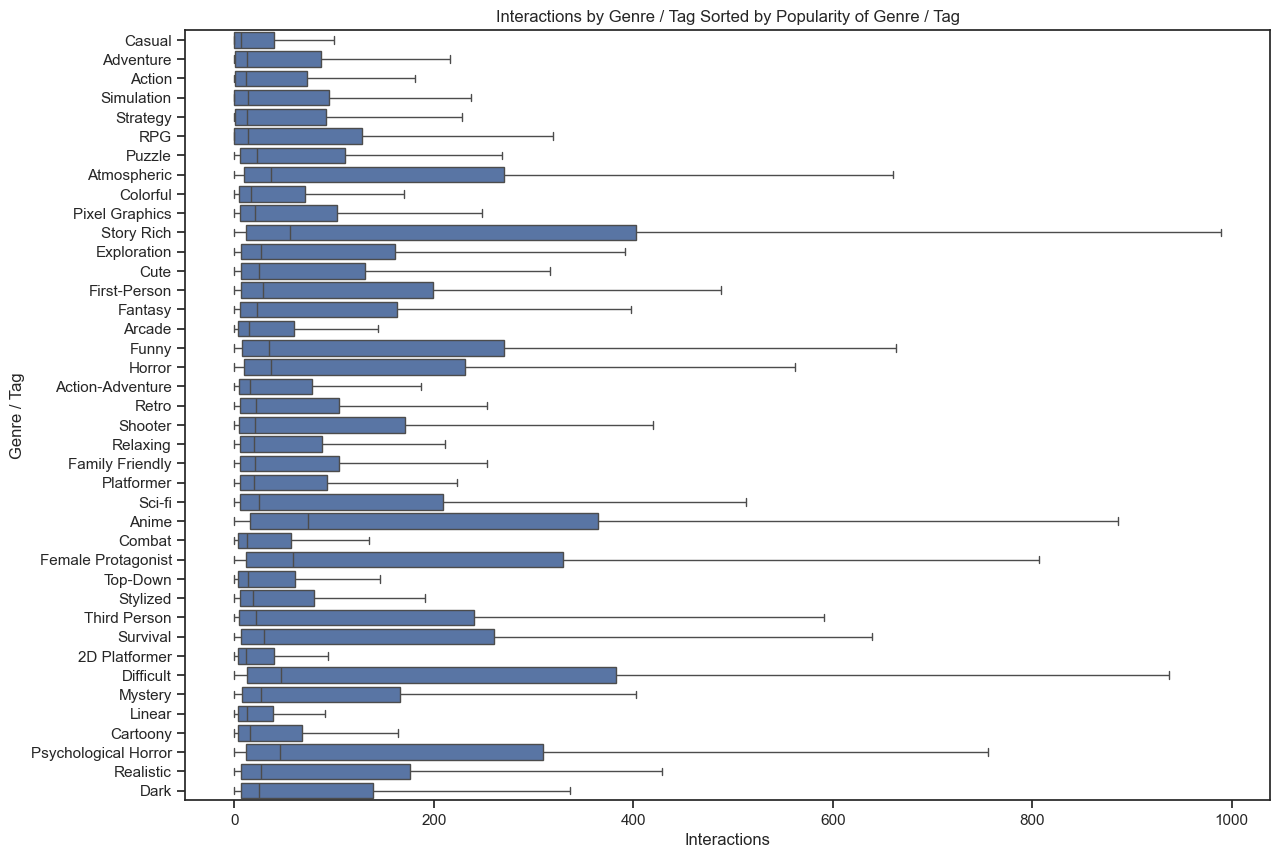

In [675]:
sns.set_theme(style="ticks")

top_genres_tags = genres_tags_filtered_df['Genre / Tags'].value_counts().head(40).index

plot_df = genres_tags_filtered_df[genres_tags_filtered_df['Genre / Tags'].isin(top_genres_tags)]

plt.figure(figsize=(14, 10))

ax = sns.boxplot(
    data=plot_df,
    x="Interactions",
    y="Genre / Tags",
    showfliers=False,
    order=top_genres_tags
)

ax.set_title("Interactions by Genre / Tag Sorted by Popularity of Genre / Tag")
ax.set_xlabel("Interactions")
ax.set_ylabel("Genre / Tag")

plt.show()

This code creates a horizontal bar chart of Interactions by Genre / Tag Sorted by Popularity of Genre / Tag.  Interactions are people who have given the game a possitive or negative review.  This visualisation shows statistical analysis of the interactions with the top 40 most popular "Genre / Tag"'s.  
  
The box shows where the middle 50% of the values are.  
The line in the center of the box is the median.  
The left edge is the 25th percentile meaning 25% of the values are under it.  
The Right edge is the 75th percentile meaning 75% of the values are under it.  
The whiskers show the highest and lowest values ignoring outliers.  
  
Most of the "Genre / Tag" have a median close to the low end and a left squew. This means the majority of games recieve low to no interactions.

Some "Genre / Tag" like 'Story Rich', 'Atmaspheric' or 'Funny' have much wider spreads this sugests the games in these tags vary a lot in interactions.

Overall there doesn't seem to be correlation between the popularity of the tag and the interactions with the game.

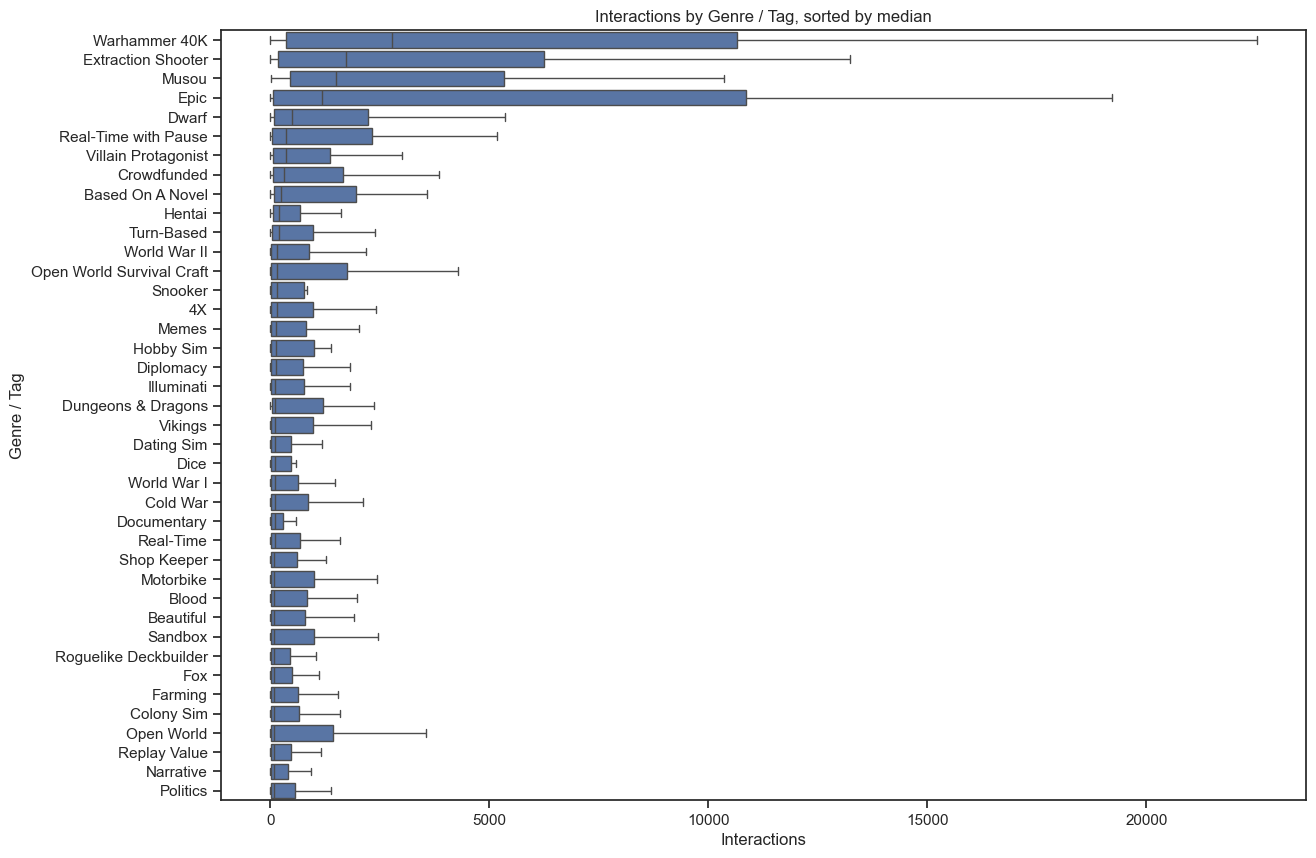

In [666]:
sns.set_theme(style="ticks")

top_genres_tags = genres_tags_filtered_df.groupby("Genre / Tags")["Interactions"].median().sort_values(ascending=False).head(40).index

plot_df = genres_tags_filtered_df[genres_tags_filtered_df['Genre / Tags'].isin(top_genres_tags)]

plt.figure(figsize=(14, 10))

ax = sns.boxplot(
    data=plot_df,
    x="Interactions",
    y="Genre / Tags",
    showfliers=False,
    order=top_genres_tags
)

ax.set_title("Interactions by Genre / Tag, sorted by median")
ax.set_xlabel("Interactions")
ax.set_ylabel("Genre / Tag")

plt.show()

This code creates a horizontal bar chart of Interactions by Genre / Tag, sorted by median.  
  
It shows which Genre / Tag has the highest user engagment.  
  
Warhammer 40K, Extraction Shooter, Musou, and Epic have the highest medium interactions meaning that these games recieve more engagment.  This may be to do with strong niche communities.
It is worth noting that a game can be described as epic and not actualy be the type epic, like a game can be described as nostalgic.  

Some tags for example Warhammer 40K and Epic have very wide boxes and whiskers, this shows that there is a great deal of variation meaning some games in this tag recieve much higher interactions than others.

The magority of Genre / Tag's have a 25th percentile at 0 meaning that 25% of the games in those tags get no interactions.


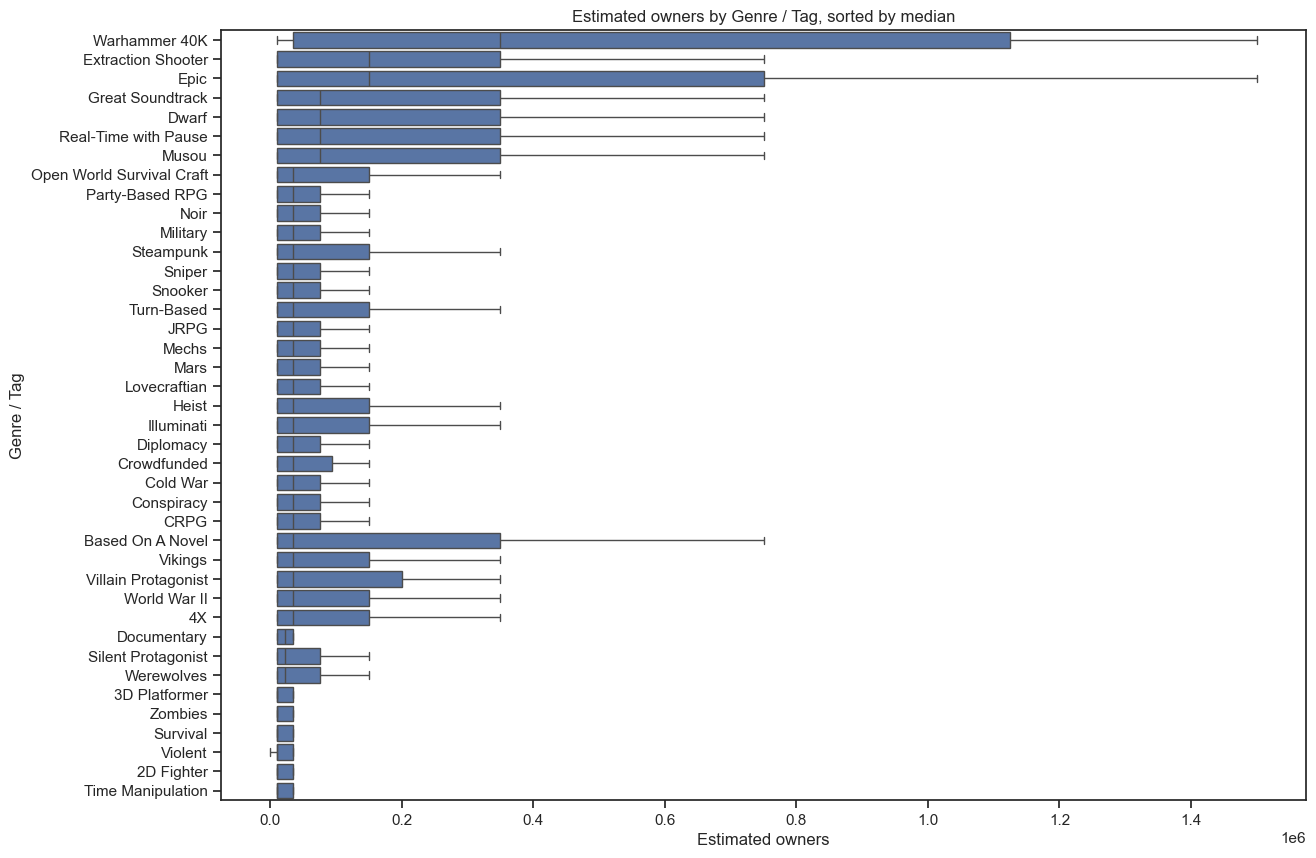

In [621]:
sns.set_theme(style="ticks")

top_genres_tags = genres_tags_filtered_df.groupby("Genre / Tags")["Estimated owners middle"].median().sort_values(ascending=False).head(40).index

plot_df = genres_tags_filtered_df[genres_tags_filtered_df['Genre / Tags'].isin(top_genres_tags)]

plt.figure(figsize=(14, 10))

ax = sns.boxplot(
    data=plot_df,
    x="Estimated owners middle",
    y="Genre / Tags",
    showfliers=False,
    order=top_genres_tags
)

ax.set_title("Estimated owners by Genre / Tag, sorted by median")
ax.set_xlabel("Estimated owners")
ax.set_ylabel("Genre / Tag")

plt.show()

This code creates a horizontal bar chart of Estimated owners by Genre / Tag, sorted by median.

The graph looks like it goes up in steps as the original data is the average of range data making the infered data unreliable.

Warhammer 40K has the highest median by a large margin.  The spread is also very wide sugesting high varience but relitivly high ownership.

Extraction Shooter, Epic, Great Soundtrack, Dwarf, Real-Time with Pause, and Musou also have higher ownership compared to games lower in the chart.

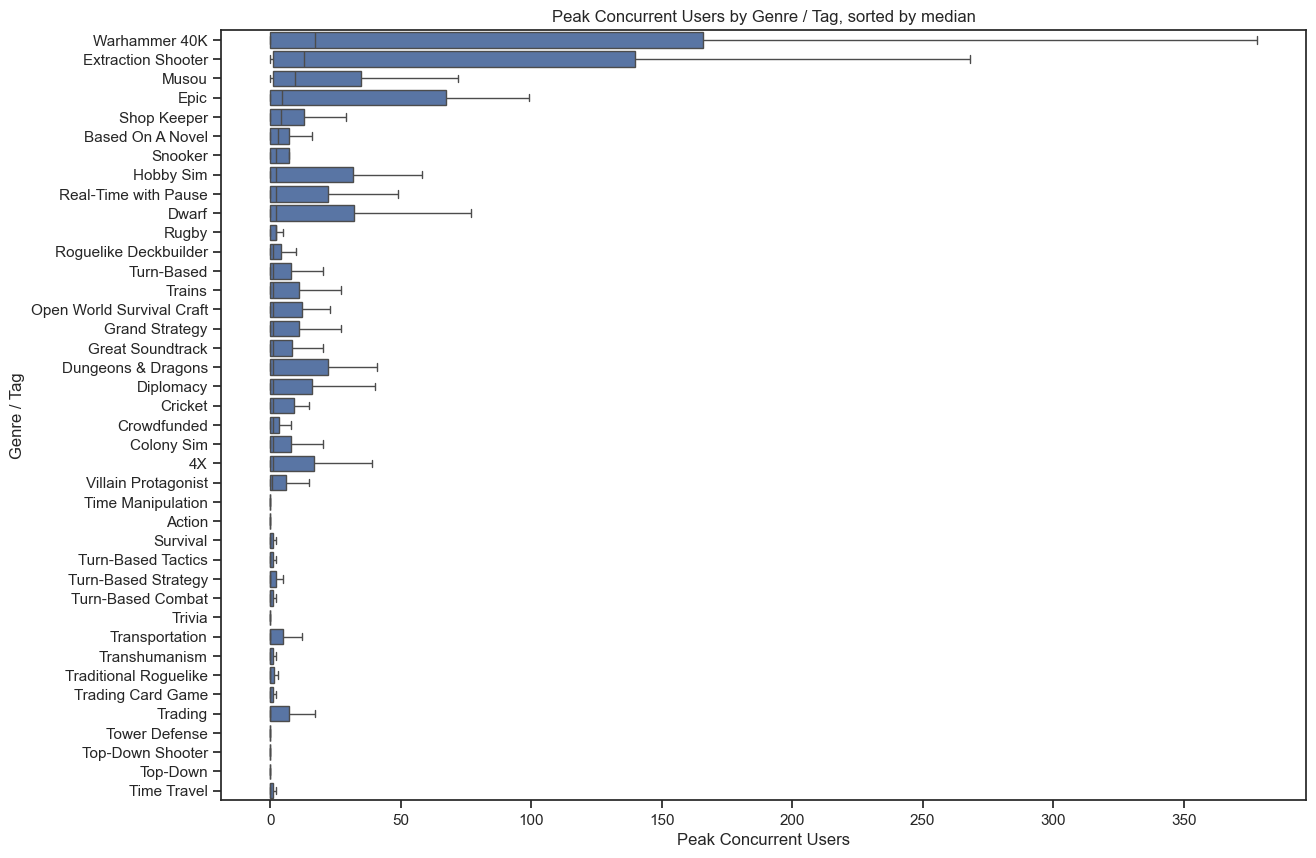

In [622]:
sns.set_theme(style="ticks")

top_genres_tags = genres_tags_filtered_df.groupby("Genre / Tags")["Peak CCU"].median().sort_values(ascending=False).head(40).index

plot_df = genres_tags_filtered_df[genres_tags_filtered_df['Genre / Tags'].isin(top_genres_tags)]

plt.figure(figsize=(14, 10))

ax = sns.boxplot(
    data=plot_df,
    x="Peak CCU",
    y="Genre / Tags",
    showfliers=False,
    order=top_genres_tags
)

ax.set_title("Peak Concurrent Users by Genre / Tag, sorted by median")
ax.set_xlabel("Peak Concurrent Users")
ax.set_ylabel("Genre / Tag")

plt.show()

This code creates a horizontal bar chart of Peak Concurrent Users by Genre / Tag, sorted by median.  Peak Concurrent Users is a measure of how popular the game was and is a measure of how viral a game was.

Warhammer 40K and Extraction Shooter have the highest peak concurrent players.

There a a few games such as Hobby sim, real time with pause, dungeon and dragons, 4x and diplomacy which have high range relitive to their median which may indicate one or two games with a high player count.

The Genre / Tag shop keeper is at the top of the concurrent players graph but doesn't apear in the graphs for estimated owners and at the lower half on the interaction graph.  This means the Genre / Tag has high peak concurrent players, limited interactions and few people owning it.  This seems to be the result of one viral game which didn't have any foundation other than virality.

Again most Genre / Tags have a 25th percentile at 0 meaning 25% of games dont get any players.

In [623]:
top_genres_tags = genres_tags_filtered_df.groupby("Genre / Tags")["Interactions"].median().sort_values(ascending=False).head(18).index
top_genres_tags

Index(['Warhammer 40K', 'Extraction Shooter', 'Musou', 'Epic', 'Dwarf',
       'Great Soundtrack', 'Real-Time with Pause', 'Villain Protagonist',
       'Crowdfunded', 'Based On A Novel', 'Hentai', 'Turn-Based',
       'World War II', 'Open World Survival Craft', 'Snooker', '4X', 'Memes',
       'Diplomacy'],
      dtype='str', name='Genre / Tags')

This code gets the 18 most popular tags by interactions.

In [624]:
new_tags = list(combinations(top_genres_tags, 3))
print(new_tags)

[('Warhammer 40K', 'Extraction Shooter', 'Musou'), ('Warhammer 40K', 'Extraction Shooter', 'Epic'), ('Warhammer 40K', 'Extraction Shooter', 'Dwarf'), ('Warhammer 40K', 'Extraction Shooter', 'Great Soundtrack'), ('Warhammer 40K', 'Extraction Shooter', 'Real-Time with Pause'), ('Warhammer 40K', 'Extraction Shooter', 'Villain Protagonist'), ('Warhammer 40K', 'Extraction Shooter', 'Crowdfunded'), ('Warhammer 40K', 'Extraction Shooter', 'Based On A Novel'), ('Warhammer 40K', 'Extraction Shooter', 'Hentai'), ('Warhammer 40K', 'Extraction Shooter', 'Turn-Based'), ('Warhammer 40K', 'Extraction Shooter', 'World War II'), ('Warhammer 40K', 'Extraction Shooter', 'Open World Survival Craft'), ('Warhammer 40K', 'Extraction Shooter', 'Snooker'), ('Warhammer 40K', 'Extraction Shooter', '4X'), ('Warhammer 40K', 'Extraction Shooter', 'Memes'), ('Warhammer 40K', 'Extraction Shooter', 'Diplomacy'), ('Warhammer 40K', 'Musou', 'Epic'), ('Warhammer 40K', 'Musou', 'Dwarf'), ('Warhammer 40K', 'Musou', 'Great 

This code makes crates a list of all posible combinations of the tags.

In [625]:
intermediate_df_list = []
item_calculated = 1
items_total = len(new_tags)

for combination in new_tags:
    tag_1, tag_2, tag_3 = combination

    filtered_df = genres_tags_filtered_df[
        (genres_tags_filtered_df['Genre / Tags'] == tag_1) | (genres_tags_filtered_df['Genre / Tags'] == tag_2) | (genres_tags_filtered_df['Genre / Tags'] == tag_3)
        ].sort_values('Genre / Tags')

    average_interactions = filtered_df['Interactions'].mean()
    average_pccu = filtered_df['Peak CCU'].mean()
    average_owners = filtered_df['Estimated owners middle'].mean()

    combined_df = (
        filtered_df
        .groupby("AppID")["Genre / Tags"]
        .nunique()
        .reset_index(name="Tag_Count")
    )

    combined_df = combined_df[combined_df["Tag_Count"] == 3]

    number_of_games = len(combined_df)

    intermediate_df_list.append({
        "Tag1": tag_1,
        "Tag2": tag_2,
        "Tag3": tag_3,
        "Average Interactions": average_interactions,
        "Average PCCU": average_pccu,
        "Average Owners": average_owners,
        "Number of Games": number_of_games
    })

    print(f"Progress: {item_calculated}/{items_total} - Tag1: {tag_1}, Tag2: {tag_2}, Tag3: {tag_3}, Average Interactions: {average_interactions}, Average PCCU: {average_pccu}, Average Owners: {average_owners}, Number of Games: {number_of_games}")
    item_calculated += 1

Progress: 1/816 - Tag1: Warhammer 40K, Tag2: Extraction Shooter, Tag3: Musou, Average Interactions: 17755.46511627907, Average PCCU: 872.9147286821706, Average Owners: 1019069.7674418605, Number of Games: 0
Progress: 2/816 - Tag1: Warhammer 40K, Tag2: Extraction Shooter, Tag3: Epic, Average Interactions: 19423.94786729858, Average PCCU: 641.6824644549763, Average Owners: 990236.9668246446, Number of Games: 0
Progress: 3/816 - Tag1: Warhammer 40K, Tag2: Extraction Shooter, Tag3: Dwarf, Average Interactions: 14270.28125, Average PCCU: 640.4866071428571, Average Owners: 793526.7857142857, Number of Games: 0
Progress: 4/816 - Tag1: Warhammer 40K, Tag2: Extraction Shooter, Tag3: Great Soundtrack, Average Interactions: 9640.258826280104, Average PCCU: 251.87397708674305, Average Owners: 533244.0963292028, Number of Games: 0
Progress: 5/816 - Tag1: Warhammer 40K, Tag2: Extraction Shooter, Tag3: Real-Time with Pause, Average Interactions: 11042.911980440098, Average PCCU: 557.5819070904646, Av

This code goes through the new_tags list filters on all 3 of the tags, extracts the mean from 'Interactions', 'Peak CCU' and 'Estimated owners middle' columns.  

It then combines the data on 'AppID' and counts all the games which contained all 3 tags.

In [626]:
new_tags_df = pd.DataFrame(
    intermediate_df_list,
    columns=["Tag1", "Tag2", "Tag3", "Average Interactions", "Average PCCU", "Average Owners", "Number of Games"]
)
new_tags_df.sort_values("Number of Games", ascending=False).head(10)

,Tag1,Tag2,Tag3,Average Interactions,Average PCCU,Average Owners,Number of Games
794,Turn-Based,4X,Diplomacy,3133.807336,143.712251,247850.783476,23
578,Great Soundtrack,Turn-Based,4X,6948.541985,189.580602,414870.528364,21
573,Great Soundtrack,Hentai,Memes,6702.416252,186.114416,377710.971965,16
579,Great Soundtrack,Turn-Based,Memes,6382.115161,170.933527,381217.835520,14
534,Great Soundtrack,Real-Time with Pause,Turn-Based,7155.334451,193.323023,423177.662654,12
649,Real-Time with Pause,4X,Diplomacy,5351.622997,318.491046,338312.912347,12
512,Dwarf,Turn-Based,4X,3191.919711,126.633181,254495.814307,9
584,Great Soundtrack,World War II,Memes,7348.762863,199.473517,427348.668281,8
457,Dwarf,Great Soundtrack,Turn-Based,7155.919097,185.669019,422303.229853,7
379,Epic,Great Soundtrack,Turn-Based,7312.232836,184.779733,428065.985860,6


In [627]:
new_tags_df["Tag Combination"] = (
    new_tags_df["Tag1"] + ", " + new_tags_df["Tag2"] + ", " + new_tags_df["Tag3"]
)

fig = px.scatter(
    new_tags_df,
    x="Average PCCU",
    y="Average Interactions",
    hover_name="Tag Combination",
    hover_data={
        "Number of Games": True,
        "Average PCCU": True,
        "Average Interactions": True,
        "Average Owners": True
    },
    color="Number of Games",
    title="Average Interactions vs Average Peak Concurrent",
    labels={
        "Average PCCU": "Average Peak Concurrent Users",
        "Average Interactions": "Average Interactions",
        "Number of Games": "Number of Games",
        "Average Owners": "Average Owners"
    }
)

fig.show()

This code creates a graph of average peak users by combined tags vs average peak concurrent users by combined graphs.
Sadly there are not enough games yet on steam for every iteration of 3 tags to have some games.

There seems to be a core positive correlation of tags based on interactions and current users.  But as well as this theres a line on top which is tags with higher intractions than concurrent users and a line on the bottom of games with higher average concurrent users and lower interactions.

## Statistical analysis

In [ ]:
to_rename = {'Estimated owners middle': 'Estimated Owners',
            'Peak CCU': 'Peak Players',
            'Positive': 'Positive Reviews',
            'Negative': 'Negative Reviews',
            'Interactions': 'Total Reviews',
            'Median playtime forever': 'Median playtime'
            }

correlation_coefficient = steam_games_df[['Estimated owners middle', 'Peak CCU', 'Interactions' ,'Positive', 'Negative', 'Price', 'Median playtime forever']].rename(columns=to_rename).corr(numeric_only=True)

fig = px.imshow(
    correlation_coefficient,
    text_auto=True,
    color_continuous_scale="RdYlGn",
    zmin=-1,
    zmax=1,
    title="Correlation Heatmap for Steam Games Data"
)

fig.update_xaxes(
    side="top",
    tickangle=20
)

fig.update_layout(
    margin=dict(t=120)
)

fig.show()

This is a correlation heatmap, correlation is the covarience of two columns over the the standard deviation of the two columns multiplied together.  It compares how strong from +1 to -1 two numeric columns relate to each other.
+1 is a perfect positive correlation, on a graph the data points would look like a line going from the bottom left to the top right.  Where -1 is a perfect negative correlation, a graph would have points going top left to bottom right.

The strogest relationship is Total reviews and positive reviews, this is expected though as total reviews include positive reviews.

Estimated owners has a moderatly strong relationship with Peak players and Total Reviews of 0.64 and 0.76  this sugests that games with more owners generally recieve more reviews and peak player count.  These correlations would normally be expected to be higher but steam has a culteral occurance where people will buy a group of hugly discounted games then never play them, howevr correlation does not prove causation.

Price however has almost no correlation with any other columns with correlations all close to 0.  This sugests that price does not have a linier relationship with owners or reviews and that price is based on somthing other than popularity.  I thought price would be correlated to median playtime ie a longer game would be a higher price but this is not the case the correlation is 0.

## Graphical and numerical reporting

### Audience focussed charts

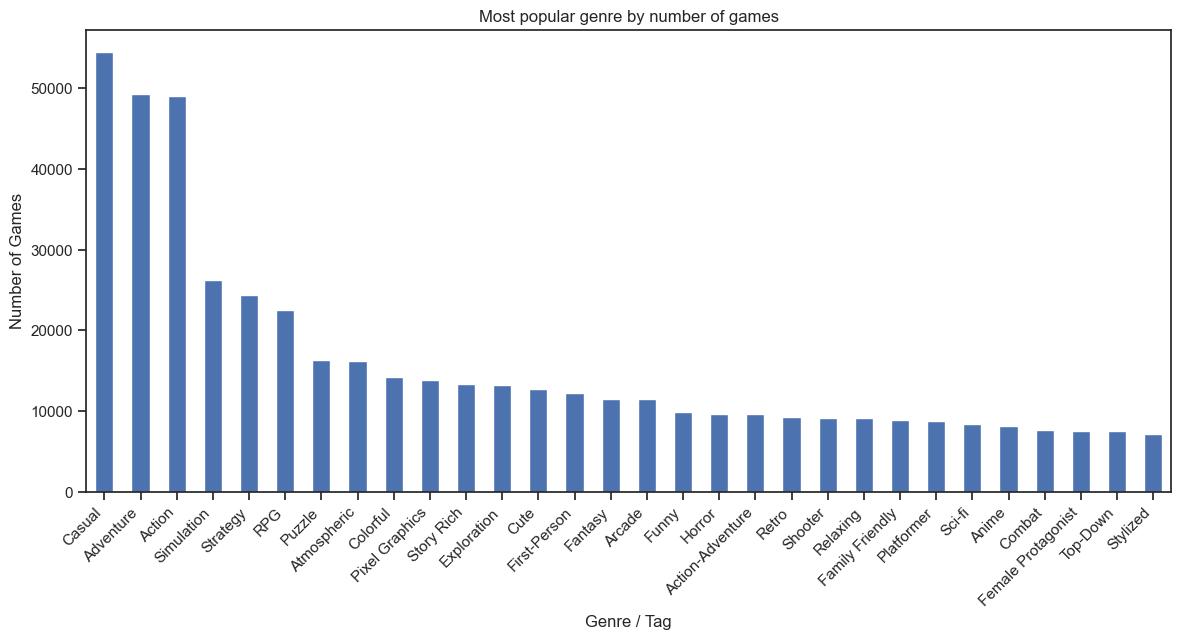

In [655]:
top_genres_tags = genres_tags_filtered_df['Genre / Tags'].value_counts().head(30).index

plot_df = genres_tags_filtered_df[genres_tags_filtered_df['Genre / Tags'].isin(top_genres_tags)]

plot_df["Genre / Tags"].value_counts().plot(kind="bar", figsize=(14, 6))

plt.title("Most popular genre by number of games")
plt.xlabel("Genre / Tag")
plt.ylabel("Number of Games")
plt.xticks(rotation=45, ha="right")

plt.show()

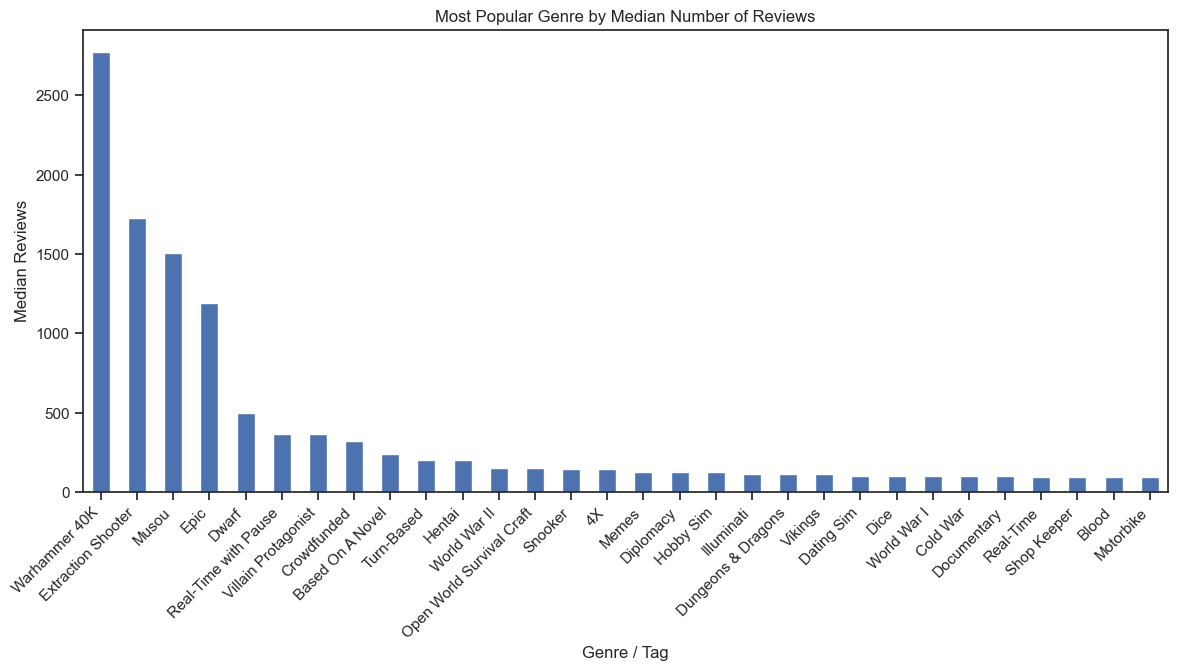

In [674]:
top_genres_tags = (genres_tags_filtered_df.groupby("Genre / Tags")["Interactions"]
    .median().sort_values(ascending=False).head(30).index)

plot_df = genres_tags_filtered_df[genres_tags_filtered_df["Genre / Tags"].isin(top_genres_tags)]

bar_df = (plot_df.groupby("Genre / Tags")["Interactions"].median().sort_values(ascending=False))

bar_df.plot(kind="bar", figsize=(14, 6))

plt.title("Most Popular Genre by Median Number of Reviews")
plt.xlabel("Genre / Tag")
plt.ylabel("Median Reviews")
plt.xticks(rotation=45, ha="right")

plt.show()

In [646]:
new_tags_df["Tag Combination"] = (
    new_tags_df["Tag1"] + ", " +
    new_tags_df["Tag2"] + ", " +
    new_tags_df["Tag3"]
)

top_10_interactions = new_tags_df.nlargest(10, "Average Interactions")
top_10_pccu = new_tags_df.nlargest(10, "Average PCCU")

plot_df = (
    pd.concat([top_10_interactions, top_10_pccu])
    .drop_duplicates()
    .sort_values("Average Interactions", ascending=False)
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=plot_df["Tag Combination"],
        y=plot_df["Average Interactions"],
        name="Average Interactions",
        yaxis="y",
        offsetgroup=1
    )
)

fig.add_trace(
    go.Bar(
        x=plot_df["Tag Combination"],
        y=plot_df["Average PCCU"],
        name="Average PCCU",
        yaxis="y2",
        offsetgroup=2
    )
)

fig.update_layout(
    title="Top 10 Average interaction and top 10 Average Peak Player Count combined.",
    xaxis=dict(
        title="Tag Combination",
        tickangle=45
    ),
    yaxis=dict(
        title="Average Interactions",
        side="left"
    ),
    yaxis2=dict(
        title="Average PCCU",
        overlaying="y",
        side="right"
    ),
    barmode="group",
    height=700
)

fig.show()

This code creates a clustered bar chart of the top 10 Average interaction and top 10 Average Peak Player Count combined into one graph.  
  
It aims to show the combination of tags that would create the most interactions and player count based on the average interactions and player count of the individual tags.

### Main Findings

This does explain why Bungie, a famous game development company thought Marathon was a good idea as its based on a setting similar to warhammer 40K and is an extraction shooter, two of the most interacted with tags.

### Recommendations